/tmp/ipykernel_81269/2068222507.py:55: FutureWarning: The 'color' parameter has been deprecated since v0.8.0 and will be removed in v0.12.0. Please use 'fill' instead.
  fig.plot(x=lcdata.vs, y=lcdata.thick, style="t0.1c", pen="0.01p", color="red",label="Layer-cake")
/tmp/ipykernel_81269/2068222507.py:58: FutureWarning: The 'color' parameter has been deprecated since v0.8.0 and will be removed in v0.12.0. Please use 'fill' instead.
  fig.plot(x=bsdata.vs, y=bsdata.thick, style="c0.1c", pen="0.01p", color="green",label="Bspline")


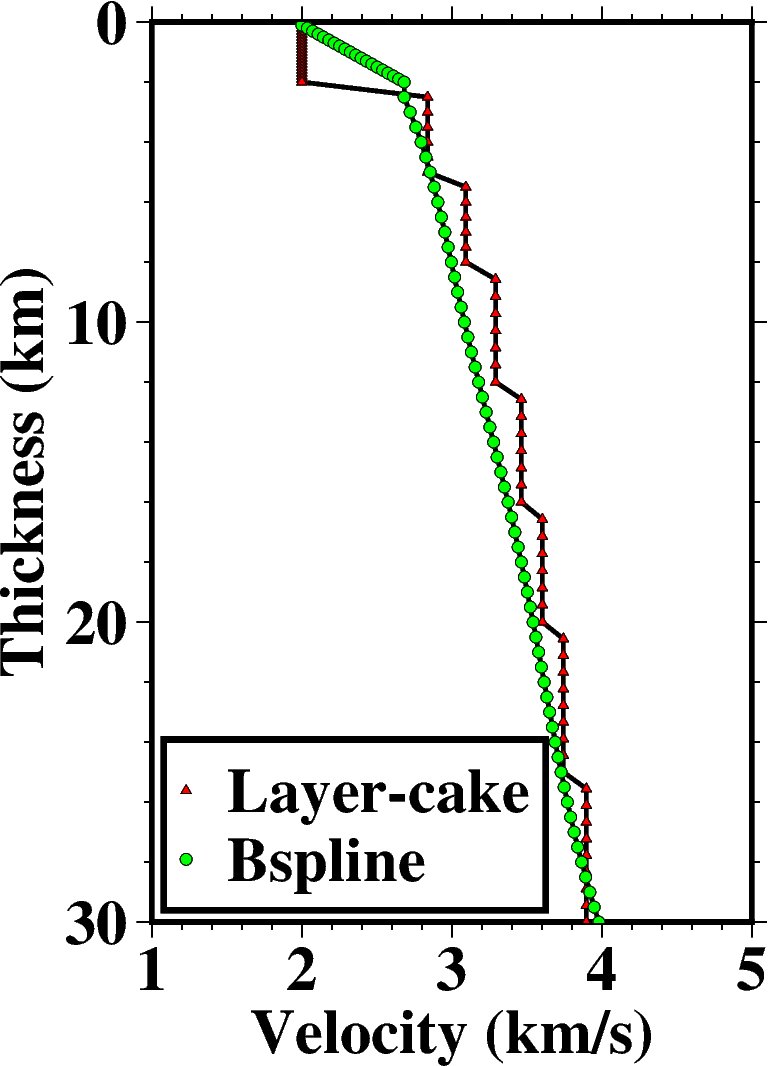

In [24]:
import obspy
from obspy.signal.cross_correlation import xcorr_pick_correction
from obspy import read
from obspy import Stream
import sys,glob
import os
import matplotlib.pyplot as plt
import numpy as np
# from sklearn import preprocessing
import pandas as pd
from matplotlib import cm # color map
import scipy
from scipy.stats import norm
from scipy.interpolate import interp1d

import statistics as st
import math
import pygmt
# ===========================================================================
# pygmt.show_versions()
'''
Compare the input model for Bspline and Layer-cake
'''
#
lcdir="/data2/longhv/Projects/MCMC_CHT_test_Layercake_same_bspline_scale/CHT02/MonteCarlo/01240"
#
bsdir="/data2/longhv/Projects/MCMC_CHT_test_Bspline_same_layercake_scale/CHT02/MonteCarlo/01240"
#
lcdata=pd.read_csv(f"{lcdir}/Initial.mod",
                    skiprows = None,
                    delim_whitespace = True,
                    names = ["thick","vs","vp","vpvs","rho","qs","qp"])
lcdata['dep']=lcdata["thick"]-lcdata["thick"][0]
#
bsdata=pd.read_csv(f"{bsdir}/Initial.mod",
                    skiprows = None,
                    delim_whitespace = True,
                    names = ["thick","vs","vp","vpvs","rho","qs","qp"])
#
bsdata['dep']=bsdata["thick"]-bsdata["thick"][0]
#
fig = pygmt.Figure()
# Config the figure 
pygmt.config(FONT_LABEL="15p,Times-Bold,black")
pygmt.config(FONT_TITLE="15p,Times-Bold,black")
pygmt.config(FONT_ANNOT_PRIMARY="15p,Times-Bold,black")
pygmt.config(FONT_ANNOT_SECONDARY="15p,Times-Roman,black")
# pygmt.grd2cpt(grid, cmap='seis', continuous=True)
# pygmt.makecpt(cmap="jet", series=(0.0,2.5,0.01),reverse=True, continuous=True)
fig.basemap(frame=["WSne", 'xaf+l"Velocity (km/s)"', 'yaf+l"Thickness (km)"'],
                region=[1,5, 0, 30],
                projection='X2i/-3i')
#
fig.plot(x=lcdata.vs, y=lcdata.thick, pen="1.0p")
fig.plot(x=lcdata.vs, y=lcdata.thick, style="t0.1c", pen="0.01p", color="red",label="Layer-cake")
#
fig.plot(x=bsdata.vs, y=bsdata.thick, pen="1.0p")
fig.plot(x=bsdata.vs, y=bsdata.thick, style="c0.1c", pen="0.01p", color="green",label="Bspline")
#
fig.legend(position="jBL+o0.1c", box=True)
fig.savefig(f"00_comparison_input.png",crop=True, dpi=300, transparent=False)
fig.show()

/tmp/ipykernel_81269/3433579225.py:35: FutureWarning: The 'color' parameter has been deprecated since v0.8.0 and will be removed in v0.12.0. Please use 'fill' instead.
  fig.plot(x=lcdata.vs, y=lcdata.dep, style="t0.1c", pen="0.01p", color="red",label="input setup")
/tmp/ipykernel_81269/3433579225.py:38: FutureWarning: The 'color' parameter has been deprecated since v0.8.0 and will be removed in v0.12.0. Please use 'fill' instead.
  fig.plot(x=bsdata.vs, y=bsdata.thick, style="c0.1c", pen="0.01p", color="green",label="MCMC characterized")


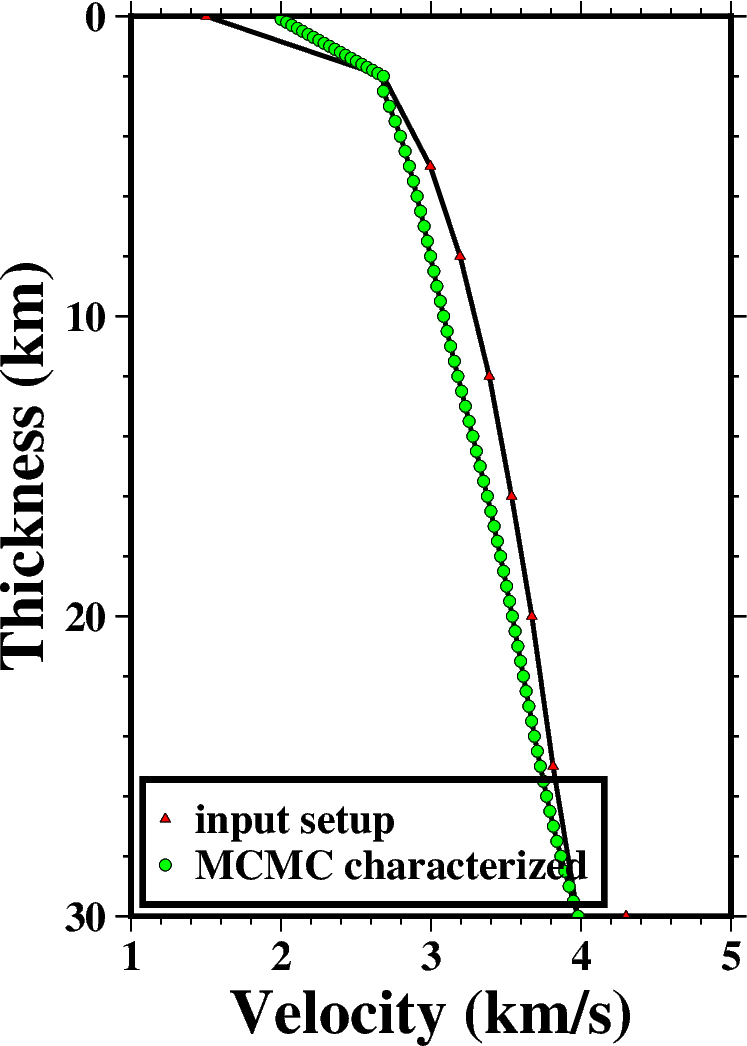

In [33]:
'''
Compare the input model for Bspline and Layer-cake
'''
#
inidir="/home/longhv/Working/Projects/MCMC_CHT_test_Bspline_same_layercake_scale/CHT02/query_data/01240"
#
indir="/data2/longhv/Projects/MCMC_CHT_test_Bspline_same_layercake_scale/CHT02/MonteCarlo/01240"
#
lcdata=pd.read_csv(f"{inidir}/01240_depth_vs.txt",
                    skiprows = None,
                    delim_whitespace = True,
                    header=0)
# lcdata['dep']=lcdata["thick"]-lcdata["thick"][0]
#
bsdata=pd.read_csv(f"{indir}/Initial.mod",
                    skiprows = None,
                    delim_whitespace = True,
                    names = ["thick","vs","vp","vpvs","rho","qs","qp"])
#
bsdata['dep']=bsdata["thick"]-bsdata["thick"][0]
#
fig = pygmt.Figure()
# Config the figure 
pygmt.config(FONT_LABEL="15p,Times-Bold,black")
pygmt.config(FONT_TITLE="15p,Times-Bold,black")
pygmt.config(FONT_ANNOT_PRIMARY="10p,Times-Bold,black")
pygmt.config(FONT_ANNOT_SECONDARY="10p,Times-Roman,black")
# pygmt.grd2cpt(grid, cmap='seis', continuous=True)
# pygmt.makecpt(cmap="jet", series=(0.0,2.5,0.01),reverse=True, continuous=True)
fig.basemap(frame=["WSne", 'xaf+l"Velocity (km/s)"', 'yaf+l"Thickness (km)"'],
                region=[1,5, 0, 30],
                projection='X2i/-3i')
#
fig.plot(x=lcdata.vs, y=lcdata.dep, pen="1.0p")
fig.plot(x=lcdata.vs, y=lcdata.dep, style="t0.1c", pen="0.01p", color="red",label="input setup")
#
fig.plot(x=bsdata.vs, y=bsdata.thick, pen="1.0p")
fig.plot(x=bsdata.vs, y=bsdata.thick, style="c0.1c", pen="0.01p", color="green",label="MCMC characterized")
#
fig.legend(position="jBL+o0.1c", box=True)
fig.savefig(f"00_comparison_input_initial_Bspline.png",crop=True, dpi=300, transparent=False)
fig.show()

In [2]:
import obspy
from obspy.signal.cross_correlation import xcorr_pick_correction
from obspy import read
from obspy import Stream
import sys,glob
import os
import matplotlib.pyplot as plt
import numpy as np
# from sklearn import preprocessing
import pandas as pd
from matplotlib import cm # color map
import scipy
from scipy.stats import norm
from scipy.interpolate import interp1d

import statistics as st
import math
import pygmt
'''
Compare the input model for Bspline and Layer-cake
'''
#
inidir="./CHT02/query_data/01240"
#
indir="CHT02/MonteCarlo/01240"
#
lcdata=pd.read_csv(f"{inidir}/01240_depth_vs_interpolated.txt",
                    skiprows = None,
                    delim_whitespace = True,
                    header=0)
# lcdata['dep']=lcdata["thick"]-lcdata["thick"][0]
#
bsdata=pd.read_csv(f"{indir}/Initial.mod",
                    skiprows = None,
                    delim_whitespace = True,
                    names = ["thick","vs","vp","vpvs","rho","qs","qp"])
#
bsdata['dep']=bsdata["thick"]-bsdata["thick"][0]
#
fig = pygmt.Figure()
# Config the figure 
pygmt.config(FONT_LABEL="15p,Times-Bold,black")
pygmt.config(FONT_TITLE="15p,Times-Bold,black")
pygmt.config(FONT_ANNOT_PRIMARY="10p,Times-Bold,black")
pygmt.config(FONT_ANNOT_SECONDARY="10p,Times-Roman,black")
# pygmt.grd2cpt(grid, cmap='seis', continuous=True)
# pygmt.makecpt(cmap="jet", series=(0.0,2.5,0.01),reverse=True, continuous=True)
fig.basemap(frame=["WSne", 'xaf+l"Velocity (km/s)"', 'yaf+l"Thickness (km)"'],
                region=[1,5, 0, 30],
                projection='X2i/-3i')
#
fig.plot(x=lcdata.vs, y=lcdata.dep, pen="1.0p")
fig.plot(x=lcdata.vs, y=lcdata.dep, style="t0.1c", pen="0.01p", color="red",label="input setup")
#
fig.plot(x=bsdata.vs, y=bsdata.thick, pen="1.0p")
fig.plot(x=bsdata.vs, y=bsdata.thick, style="c0.1c", pen="0.01p", color="green",label="MCMC characterized")
#
fig.legend(position="jBL+o0.1c", box=True)
fig.savefig(f"00_comparison_input_initial_layercake.png",crop=True, dpi=300, transparent=False)
fig.show()

FileNotFoundError: [Errno 2] No such file or directory: './CHT02/query_data/01240/01240_depth_vs_interpolated.txt'